In [2]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [3]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)

In [4]:
svm_clf = make_pipeline(StandardScaler(), LinearSVC(C=1, random_state=42))
svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, random_state=42))])

In [5]:
X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

In [6]:
svm_clf.decision_function(X_new)

array([ 0.66163816, -0.22035761])

## Nonlinear SVM Classification

In [7]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

In [8]:
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

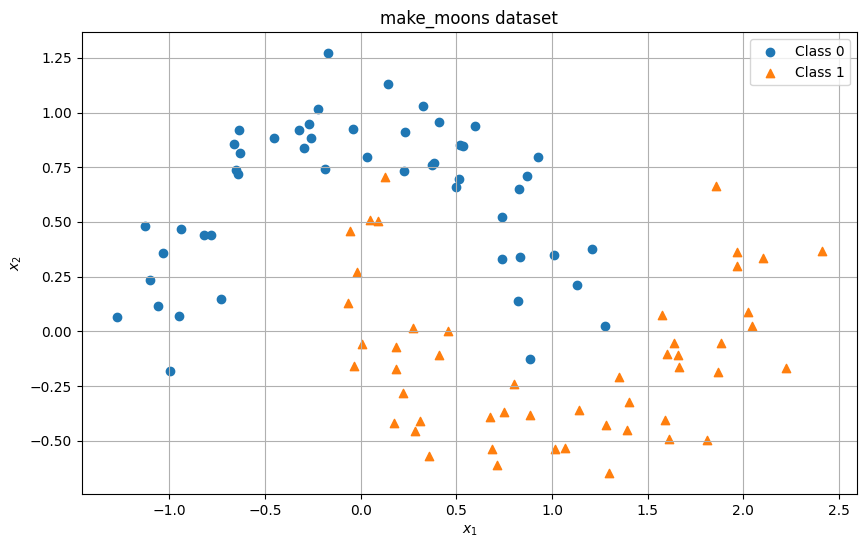

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="o", label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", label="Class 1")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("make_moons dataset")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, max_iter=10000, random_state=42))])

In [11]:
from sklearn.svm import SVC
poly_kernel_svm_clf = make_pipeline(StandardScaler(), SVC(kernel='poly', degree=3, coef0=1, C=5))
poly_kernel_svm_clf.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

In [12]:
rbf_kernel_svm_clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma=5, C=0.001))
rbf_kernel_svm_clf.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

# Exercise

1. What is the fundamental idea behind support vector machines?
   Answer: The fundamental idea behind support vector machines is to find a decision boundary that separates the classes while keeping the margin between the classes as wide as possible. 
2. What is a support vector?
   Answer: A support vector is a training instance that lies on or inside the margin of the SVM decision boundary. These instances determine the position and orientation of the separating boundary.
3. Why is it important to scale the inputs when using SVMs?
   Answer: Because they are sensitive to the scale of the input features and this might contribute to the decision boundary.
4. Can an SVM classifier output a confidence score when it classifies an instance? What about a probability?
   Answer: An SVM classifier can output a confidence score using the `decision_function()` method, which measures how far an instance is from the decision boundary. However, it does not output probabilities by default. Probabilities can be estimated, for example by setting `probability=True` in `SVC`, but this requires an additional calibration step.
5. How can you choose between LinearSVC, SVC, and SGDClassifier?
   Answer: Choose `LinearSVC` when the data is roughly linearly separable or when you only need a linear SVM, especially for larger datasets. Choose `SVC` when the dataset is not too large and you want to use the kernel trick for nonlinear classification. Choose `SGDClassifier` for very large datasets or online learning, since it can train a linear SVM using stochastic gradient descent.
6. Say you’ve trained an SVM classifier with an RBF kernel, but it seems to underfit the training set. Should you increase or decrease γ (gamma)? What about C?
   Answer: If an SVM classifier with an RBF kernel underfits the training set, we should increase `gamma` and increase `C`. Increasing `gamma` makes the decision boundary more flexible, while increasing `C` reduces regularization and allows the model to fit the training data more closely.
7. What does it mean for a model to be ϵ-insensitive?
   Answer: Adding more training instances within the margin.
8. What is the point of using the kernel trick?
   Answer: The point of using the kernel trick is to let an SVM behave as if the data were transformed into a higher-dimensional feature space, without actually computing that transformation. This allows the model to learn nonlinear decision boundaries more efficiently.

9. Train a LinearSVC on a linearly separable dataset. Then train an SVC and a SGDClassifier on the same dataset. See if you can get them to produce roughly the same model.

- Dataset: Iris dataset
- Classes: Setosa and Versicolor only
- Features: Petal length and petal width
- Goal: Train `LinearSVC`, `SVC(kernel="linear")`, and `SGDClassifier(loss="hinge")` and compare their decision boundaries.

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

X = iris.data[['petal length (cm)', 'petal width (cm)']]
y = iris.target 

X = X[y < 2]
y = y[y < 2]


,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
95,4.2,1.2
96,4.2,1.3
97,4.3,1.3
98,3.0,1.1


### Linear SVC

In [20]:
svm_clf = make_pipeline(StandardScaler(), LinearSVC(C=1, random_state=42))
svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, random_state=42))])

### Plotting of LinearSVC

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
# we get the feature names
feature_1 = X.columns[0]
feature_2 = X.columns[1]

In [23]:
# get the boundaries for the mesh grid
x0_min, x0_max = X[feature_1].min() - 0.5, X[feature_1].max() + 0.5
x1_min, x1_max = X[feature_2].min() - 0.5, X[feature_2].max() + 0.5

In [27]:
x0, x1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 300),
    np.linspace(x1_min, x1_max, 300)
)

In [35]:
x0

array([[0.5       , 0.51705686, 0.53411371, ..., 5.56588629, 5.58294314,
        5.6       ],
       [0.5       , 0.51705686, 0.53411371, ..., 5.56588629, 5.58294314,
        5.6       ],
       [0.5       , 0.51705686, 0.53411371, ..., 5.56588629, 5.58294314,
        5.6       ],
       ...,
       [0.5       , 0.51705686, 0.53411371, ..., 5.56588629, 5.58294314,
        5.6       ],
       [0.5       , 0.51705686, 0.53411371, ..., 5.56588629, 5.58294314,
        5.6       ],
       [0.5       , 0.51705686, 0.53411371, ..., 5.56588629, 5.58294314,
        5.6       ]])

In [30]:
# Convert grid into a DataFrame with the same column names as X
X_grid = pd.DataFrame(
    np.c_[x0.ravel(), x1.ravel()],
    columns=X.columns
)

In [31]:
X_grid

,petal length (cm),petal width (cm)
0,0.500000,-0.4
1,0.517057,-0.4
2,0.534114,-0.4
3,0.551171,-0.4
4,0.568227,-0.4
...,...,...
89995,5.531773,2.3
89996,5.548829,2.3
89997,5.565886,2.3
89998,5.582943,2.3


In [41]:
# we get the decision scores for each point in the dataframe
decision_scores = svm_clf.decision_function(X_grid)
decision_scores

array([-2.97237719, -2.96173213, -2.95108707, ...,  4.19506974,
        4.2057148 ,  4.21635986])

In [43]:
decision_scores = decision_scores.reshape(x0.shape)
decision_scores

array([[-2.97237719, -2.96173213, -2.95108707, ...,  0.18920551,
         0.19985057,  0.21049563],
       [-2.95897965, -2.94833459, -2.93768953, ...,  0.20260305,
         0.21324811,  0.22389317],
       [-2.94558211, -2.93493705, -2.92429199, ...,  0.21600059,
         0.22664565,  0.23729071],
       ...,
       [ 1.00669197,  1.01733703,  1.02798209, ...,  4.16827466,
         4.17891972,  4.18956478],
       [ 1.02008951,  1.03073457,  1.04137963, ...,  4.1816722 ,
         4.19231726,  4.20296232],
       [ 1.03348705,  1.0441321 ,  1.05477716, ...,  4.19506974,
         4.2057148 ,  4.21635986]])

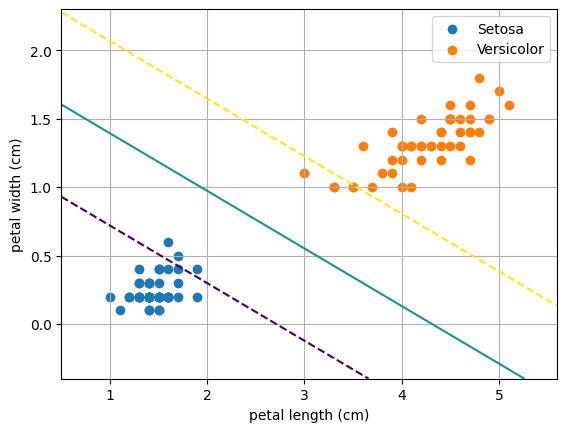

In [ ]:
plt.scatter(
    X[feature_1][y == 0],
    X[feature_2][y == 0],
    label="Setosa"
)

plt.scatter(
    X[feature_1][y == 1],
    X[feature_2][y == 1],
    label="Versicolor"
)

# plot decision boundary and margins
plt.contour(x0, x1, decision_scores,
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"]
)

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend()
plt.grid(True)
plt.show()

### For SVC

In [61]:
svc_svm_clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1, random_state=42))
svc_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=1, kernel='linear', random_state=42))])

In [ ]:
# we get the decision scores for each point in the dataframe
decision_scores = svc_svm_clf.decision_function(X_grid)
decision_scores = decision_scores.reshape(x0.shape)

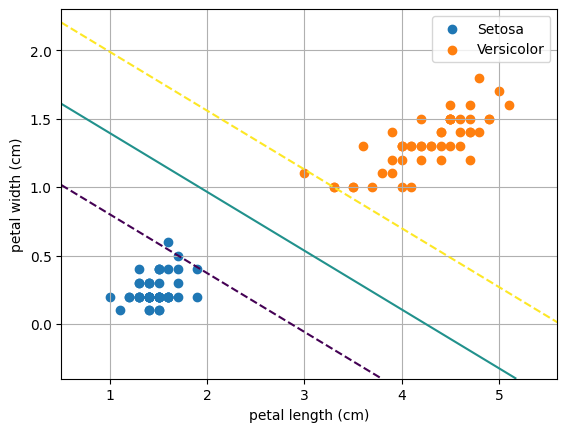

In [63]:
plt.scatter(
    X[feature_1][y == 0],
    X[feature_2][y == 0],
    label="Setosa"
)

plt.scatter(
    X[feature_1][y == 1],
    X[feature_2][y == 1],
    label="Versicolor"
)

# plot decision boundary and margins
plt.contour(x0, x1, decision_scores,
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"]
)

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend()
plt.grid(True)
plt.show()

### For SGDClassifier

In [80]:
from sklearn.linear_model import SGDClassifier
C=1
sgd_svm_clf = make_pipeline(StandardScaler(), SGDClassifier(loss='hinge', alpha=1 / (len(X) * C), max_iter=10000, tol=1e-7, random_state=42))
sgd_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdclassifier',
                 SGDClassifier(alpha=0.01, max_iter=10000, random_state=42,
                               tol=1e-07))])

In [81]:
# we get the decision scores for each point in the dataframe
decision_scores = sgd_svm_clf.decision_function(X_grid)
decision_scores = decision_scores.reshape(x0.shape)

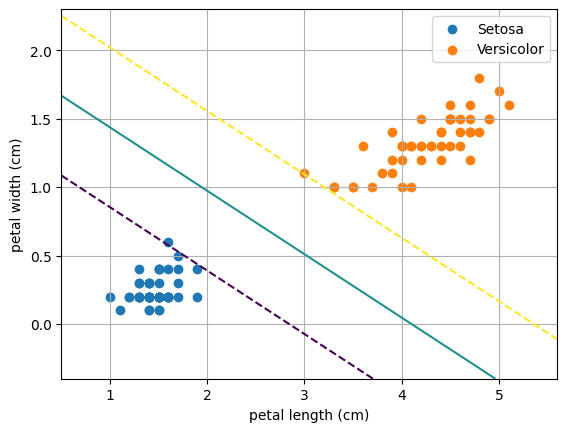

In [82]:
plt.scatter(
    X[feature_1][y == 0],
    X[feature_2][y == 0],
    label="Setosa"
)

plt.scatter(
    X[feature_1][y == 1],
    X[feature_2][y == 1],
    label="Versicolor"
)

# plot decision boundary and margins
plt.contour(x0, x1, decision_scores,
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"]
)

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend()
plt.grid(True)
plt.show()

`LinearSVC` and `SVC(kernel="linear")` produce very similar decision boundaries. `SGDClassifier(loss="hinge")` also learns a linear SVM-like boundary, but its result may differ because it uses stochastic gradient descent and is sensitive to optimization settings such as `alpha`, `max_iter`, and `tol`.

10. Train an SVM classifier on the wine dataset, which you can load using `sklearn.datasets.load_wine()`. This dataset contains the chemical analyses of 178 wine samples produced by 3 different cultivators: the goal is to train a classification model capable of predicting the cultivator based on the wine’s chemical analysis. Since SVM classifiers are binary classifiers, you will need to use one-versus-all to classify all three classes. What accuracy can you reach?

In [84]:
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
wine

{'data':      alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
 0      14.23        1.71  2.43  ...  1.04                          3.92   1065.0
 1      13.20        1.78  2.14  ...  1.05                          3.40   1050.0
 2      13.16        2.36  2.67  ...  1.03                          3.17   1185.0
 3      14.37        1.95  2.50  ...  0.86                          3.45   1480.0
 4      13.24        2.59  2.87  ...  1.04                          2.93    735.0
 ..       ...         ...   ...  ...   ...                           ...      ...
 173    13.71        5.65  2.45  ...  0.64                          1.74    740.0
 174    13.40        3.91  2.48  ...  0.70                          1.56    750.0
 175    13.27        4.28  2.26  ...  0.59                          1.56    835.0
 176    13.17        2.59  2.37  ...  0.60                          1.62    840.0
 177    14.13        4.10  2.74  ...  0.61                          1.60    560.0
 
 [178 

In [86]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

In [85]:
X = wine.data
y = wine.target

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [88]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
31,13.58,1.66,2.36,19.1,106.0,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515.0
120,11.45,2.40,2.42,20.0,96.0,2.90,2.79,0.32,1.83,3.25,0.80,3.39,625.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,13.58,2.58,2.69,24.5,105.0,1.55,0.84,0.39,1.54,8.66,0.74,1.80,750.0
114,12.08,1.39,2.50,22.5,84.0,2.56,2.29,0.43,1.04,2.90,0.93,3.19,385.0
152,13.11,1.90,2.75,25.5,116.0,2.20,1.28,0.26,1.56,7.10,0.61,1.33,425.0
136,12.25,4.72,2.54,21.0,89.0,1.38,0.47,0.53,0.80,3.85,0.75,1.27,720.0


In [107]:
ovr_svm_clf = make_pipeline(StandardScaler(), OneVsRestClassifier(LinearSVC(C=1, random_state=42, max_iter=10000)))
ovr_svm_clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('onevsrestclassifier',
                 OneVsRestClassifier(estimator=LinearSVC(C=1, max_iter=10000,
                                                         random_state=42)))])

In [108]:
ovr_svm_clf.score(X_test, y_test)

0.9814814814814815

In [109]:
from sklearn.metrics import confusion_matrix
y_pred = ovr_svm_clf.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[18,  0,  0],
       [ 1, 20,  0],
       [ 0,  0, 15]])

In [110]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=wine.target_names))

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



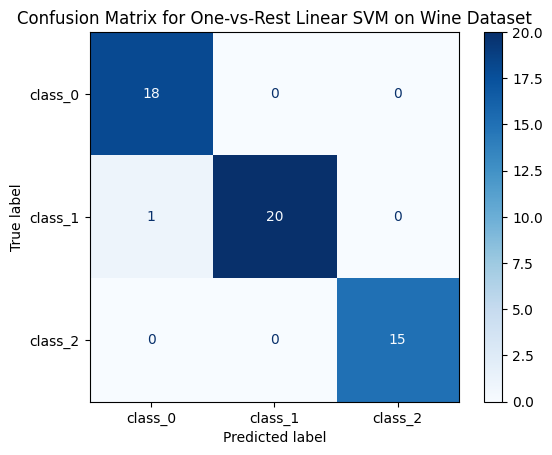

In [111]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = ovr_svm_clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=wine.target_names,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix for One-vs-Rest Linear SVM on Wine Dataset")
plt.show()

The one-versus-rest Linear SVM classifier achieved an accuracy of 0.98 on the wine test set. Out of 54 test samples, it correctly classified 53 samples and misclassified only 1 class 1 sample as class 0. The model performed perfectly on class 2, while class 0 and class 1 had a small confusion between them.

11. Train and fine-tune an SVM regressor on the California housing dataset. You can use the original dataset rather than the tweaked version we used in Chapter 2, which you can load using sklearn.datasets.fetch_california_housing(). The targets represent hundreds of thousands of dollars. Since there are over use far fewer instances (e.g., 2,000) to test many more hyperparameter combinations. What is your best model’s RMSE?

In [120]:
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR
housing = fetch_california_housing(as_frame=True)
housing

{'data':        MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
 0      8.3252      41.0  6.984127  ...  2.555556     37.88    -122.23
 1      8.3014      21.0  6.238137  ...  2.109842     37.86    -122.22
 2      7.2574      52.0  8.288136  ...  2.802260     37.85    -122.24
 3      5.6431      52.0  5.817352  ...  2.547945     37.85    -122.25
 4      3.8462      52.0  6.281853  ...  2.181467     37.85    -122.25
 ...       ...       ...       ...  ...       ...       ...        ...
 20635  1.5603      25.0  5.045455  ...  2.560606     39.48    -121.09
 20636  2.5568      18.0  6.114035  ...  3.122807     39.49    -121.21
 20637  1.7000      17.0  5.205543  ...  2.325635     39.43    -121.22
 20638  1.8672      18.0  5.329513  ...  2.123209     39.43    -121.32
 20639  2.3886      16.0  5.254717  ...  2.616981     39.37    -121.24
 
 [20640 rows x 8 columns],
 'target': 0        4.526
 1        3.585
 2        3.521
 3        3.413
 4        3.422
          ...  
 2063

In [126]:
X = housing.data
y = housing.target

X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [127]:
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]

In [ ]:
svm_reg = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
svm_reg.fit(X_train_small, y_train_small)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svr', SVR())])

In [145]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

y_train_pred = svm_reg.predict(X_train_small)
train_rmse = mean_squared_error(y_train_small, y_train_pred)
train_rmse

0.38785095554490384

In [144]:
y_pred = svm_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

0.6126815626300912

**Hyperparameter Tuning**

In [135]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_distribs = {
    'svr__C': loguniform(1, 100000),
    'svr__gamma': loguniform(0.001, 10)
}

random_search = RandomizedSearchCV(svm_reg, param_distributions=param_distribs, n_iter=100, cv=3, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=1)
random_search.fit(X_train_small, y_train_small)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('standardscaler',
                                              StandardScaler()),
                                             ('svr', SVR())]),
                   n_iter=100, n_jobs=1,
                   param_distributions={'svr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x14f2a4fe0>,
                                        'svr__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x14e88b440>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [136]:
random_search.best_params_

{'svr__C': 9.962513222055108, 'svr__gamma': 0.11400863701127326}

In [140]:
-random_search.best_score_

0.6298451938239138

In [146]:
from sklearn.metrics import root_mean_squared_error
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

0.5880400924784984

After tuning an RBF-kernel `SVR` using `RandomizedSearchCV`, the best parameters were approximately `C = 99625` and `gamma = 0.114`. The best cross-validation RMSE on the smaller training subset was about `0.629`, while the test RMSE was about `0.588`. Since the target is measured in hundreds of thousands of dollars, this corresponds to an error of roughly `$58,800`.